In [34]:
pip install mysql-connector-python pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [35]:
import mysql.connector
from mysql.connector import pooling
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [36]:
# ===============================
# CONFIGURATION
# ===============================
DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "password": "visiteur",
    "database": "classicmodels"
}
OUTPUT_DIR = "visualisations"
OUTPUT_DIR = r"C:\Users\Visiteur\Desktop\visualisations"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Dossier de travail :", os.getcwd())


Dossier de travail : c:\Program Files\Microsoft VS Code


In [37]:
%matplotlib inline

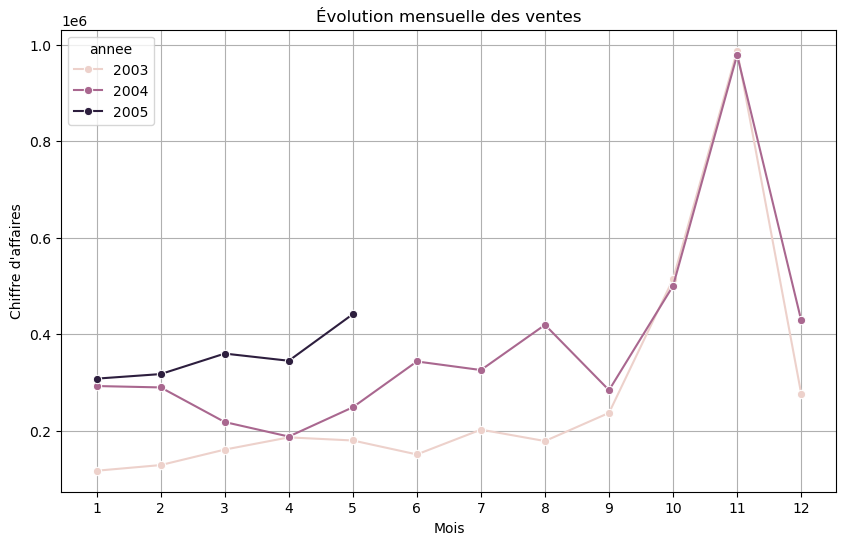

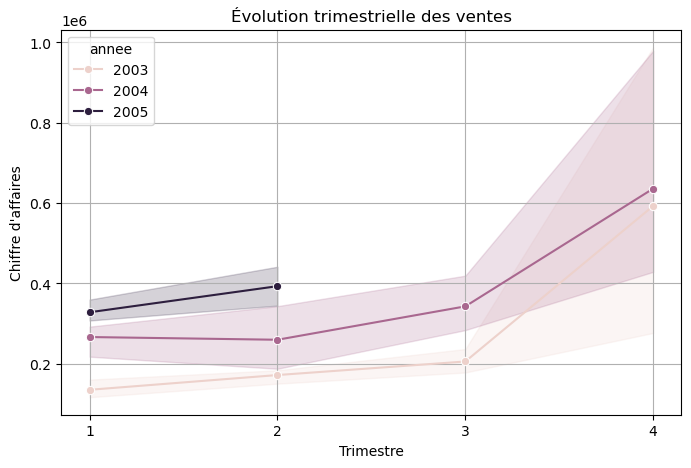

In [38]:
# -------------------------------
# Fonction pour l'évolution des ventes
# -------------------------------
def ventes_temps():
    query = """
    SELECT 
        YEAR(o.orderDate) AS annee,
        MONTH(o.orderDate) AS mois,
        QUARTER(o.orderDate) AS trimestre,
        SUM(od.quantityOrdered * od.priceEach) AS ventes
    FROM orders o
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    GROUP BY annee, mois, trimestre
    ORDER BY annee, mois;
    """
    df = fetch_data(query)

    # --- Par mois
    plt.figure(figsize=(10,6))
    sns.lineplot(data=df, x="mois", y="ventes", hue="annee", marker="o")
    plt.title("Évolution mensuelle des ventes")
    plt.xlabel("Mois")
    plt.ylabel("Chiffre d'affaires")
    plt.xticks(range(1,13))  # Affiche tous les mois
    plt.grid(True)
    plt.show()

    # --- Par trimestre
    plt.figure(figsize=(8,5))
    sns.lineplot(data=df, x="trimestre", y="ventes", hue="annee", marker="o")
    plt.title("Évolution trimestrielle des ventes")
    plt.xlabel("Trimestre")
    plt.ylabel("Chiffre d'affaires")
    plt.xticks([1,2,3,4])
    plt.grid(True)
    plt.show()

# -------------------------------
# Appel de la fonction
# -------------------------------
ventes_temps()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_10960\2072138459.py:22: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



C:\Users\Visiteur\AppData\Local\Temp\ipykernel_10960\2072138459.py:36: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




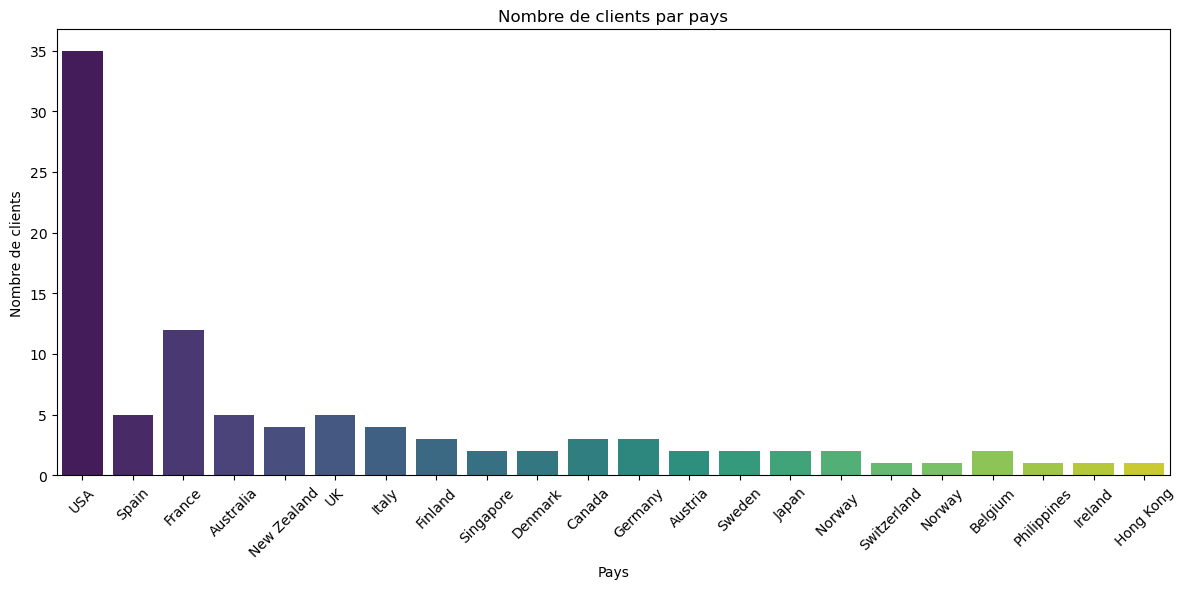

In [39]:
# ===============================
# 2) REPARTITION GEOGRAPHIQUE DES CLIENTS ET VENTES PAR PAYS
# ===============================

import plotly.express as px

def repartition_geographique():
    query = """
    SELECT 
        c.country AS pays,
        COUNT(DISTINCT c.customerNumber) AS nb_clients,
        SUM(od.quantityOrdered * od.priceEach) AS ventes
    FROM customers c
    JOIN orders o ON c.customerNumber = o.customerNumber
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    GROUP BY c.country
    ORDER BY ventes DESC;
    """
    df = fetch_data(query)

    # --- Carte choroplèthe avec les ventes par pays
    fig = px.choropleth(
        df, 
        locations="pays",
        locationmode="country names",
        color="ventes",
        hover_name="pays",
        hover_data={"nb_clients":True, "ventes":":,.2f"},
        color_continuous_scale="Viridis",
        title="Répartition des ventes par pays"
    )
    fig.show()

    # --- Bar chart pour les clients par pays
    plt.figure(figsize=(12,6))
    sns.barplot(data=df, x="pays", y="nb_clients", palette="viridis")
    plt.xticks(rotation=45)
    plt.title("Nombre de clients par pays")
    plt.xlabel("Pays")
    plt.ylabel("Nombre de clients")
    plt.tight_layout()
    plt.show()

# -------------------------------
# Appel de la fonction
# -------------------------------
repartition_geographique()


Plots seront sauvegardés ici : C:\Users\Visiteur\visualisations


C:\Users\Visiteur\AppData\Local\Temp\ipykernel_10960\3041430090.py:31: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



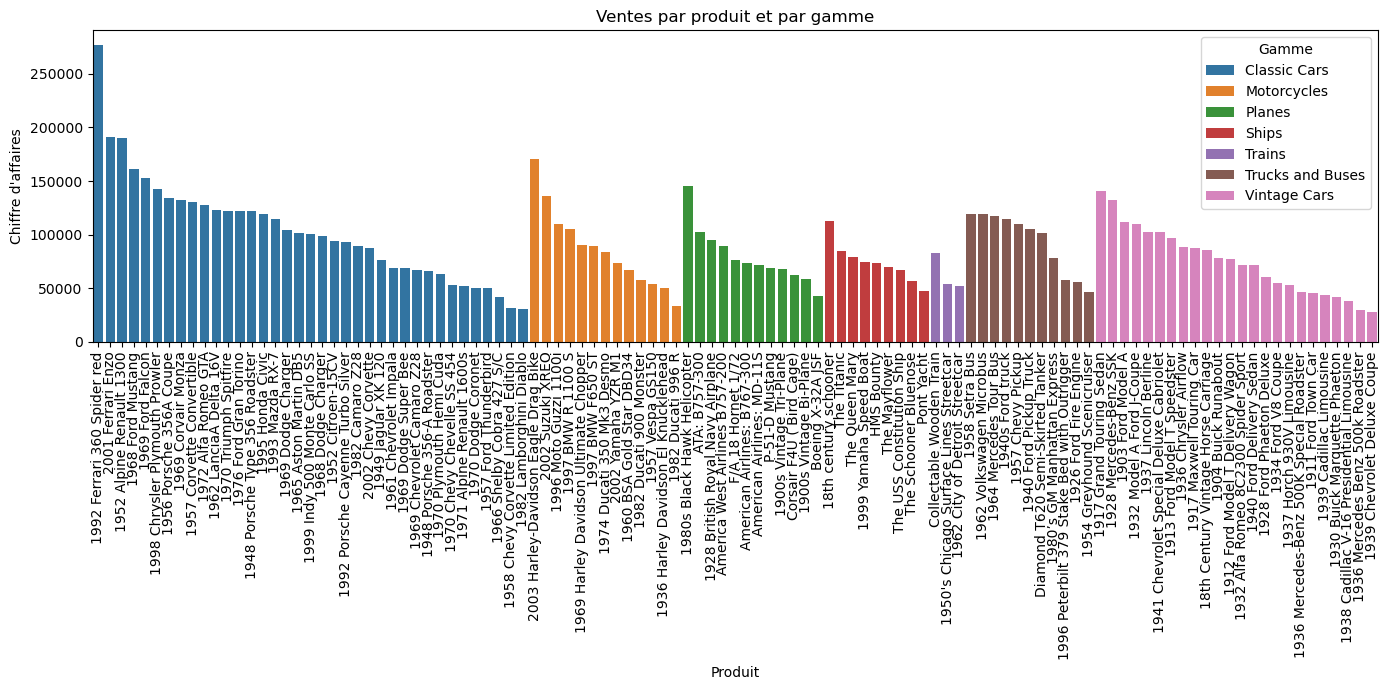

In [50]:
# ===============================
# 3) VENTES PAR GAMME DE PRODUITS & TOP PRODUITS & ETAT DES STOCKS
# ===============================

import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Dossier pour sauvegarder les plots
# -------------------------------
OUTPUT_DIR = os.path.join(os.path.expanduser("~"), "visualisations")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Plots seront sauvegardés ici :", OUTPUT_DIR)

# -------------------------------
# Connexion sécurisée MySQL
# -------------------------------
def get_connection():
    return mysql.connector.connect(
        host="localhost",
        user="root",
        password="visiteur",
        database="classicmodels"
    )

def fetch_data(query):
    conn = get_connection()
    df = pd.read_sql(query, conn)
    conn.close()
    return df

# -------------------------------
# Requête : ventes par gamme de produits
# -------------------------------
query_gamme = """
SELECT 
    p.productLine,
    p.productName,
    SUM(od.quantityOrdered * od.priceEach) AS ventes
FROM products p
JOIN orderdetails od ON p.productCode = od.productCode
GROUP BY p.productLine, p.productName
ORDER BY p.productLine, ventes DESC;
"""
df_gamme = fetch_data(query_gamme)

# -------------------------------
# Graphique : ventes par produit, groupées par gamme
# -------------------------------
plt.figure(figsize=(14,7))
sns.barplot(data=df_gamme, x="productName", y="ventes", hue="productLine", dodge=False)
plt.xticks(rotation=90)
plt.title("Ventes par produit et par gamme")
plt.xlabel("Produit")
plt.ylabel("Chiffre d'affaires")
plt.legend(title="Gamme")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ventes_gamme.png"))
plt.show()


Plots seront sauvegardés ici : C:\Users\Visiteur\visualisations


C:\Users\Visiteur\AppData\Local\Temp\ipykernel_10960\3873851714.py:31: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_10960\3873851714.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




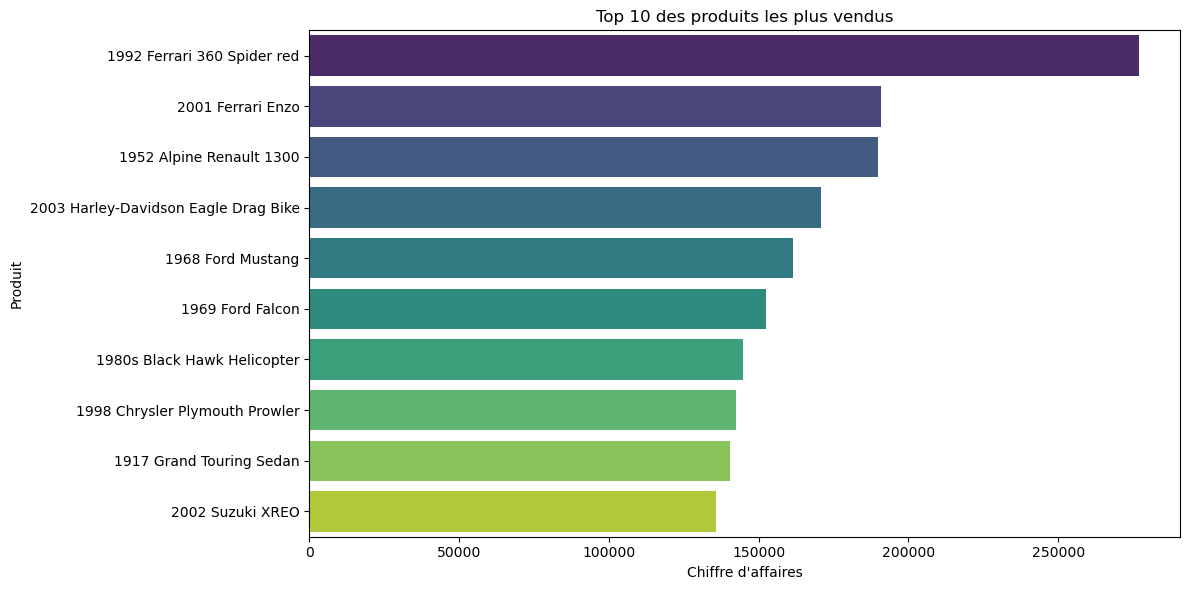

In [51]:
# -------------------------------
# 4) : TOP 10 PRODUITS LES PLUS VENDUS
# -------------------------------

import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Dossier pour sauvegarder les plots
# -------------------------------
OUTPUT_DIR = os.path.join(os.path.expanduser("~"), "visualisations")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Plots seront sauvegardés ici :", OUTPUT_DIR)

# -------------------------------
# Connexion sécurisée MySQL
# -------------------------------
def get_connection():
    return mysql.connector.connect(
        host="localhost",
        user="root",
        password="visiteur",
        database="classicmodels"
    )

def fetch_data(query):
    conn = get_connection()
    df = pd.read_sql(query, conn)
    conn.close()
    return df

# -------------------------------
# Requête : Top 10 produits les plus vendus
# -------------------------------
query_top10 = """
SELECT 
    p.productName,
    SUM(od.quantityOrdered * od.priceEach) AS ventes
FROM products p
JOIN orderdetails od ON p.productCode = od.productCode
GROUP BY p.productName
ORDER BY ventes DESC
LIMIT 10;
"""
df_top10 = fetch_data(query_top10)

# -------------------------------
# Graphique : Top 10 produits
# -------------------------------
plt.figure(figsize=(12,6))
sns.barplot(data=df_top10, x="ventes", y="productName", palette="viridis")
plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Produit")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top10_produits.png"))
plt.show()


In [46]:
import os

# Créer un dossier "visualisations" dans ton dossier utilisateur
OUTPUT_DIR = os.path.join(os.path.expanduser("~"), "visualisations")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Plots seront sauvegardés ici :", OUTPUT_DIR)

Plots seront sauvegardés ici : C:\Users\Visiteur\visualisations


Plots seront sauvegardés ici : C:\Users\Visiteur\visualisations


C:\Users\Visiteur\AppData\Local\Temp\ipykernel_10960\205205334.py:31: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



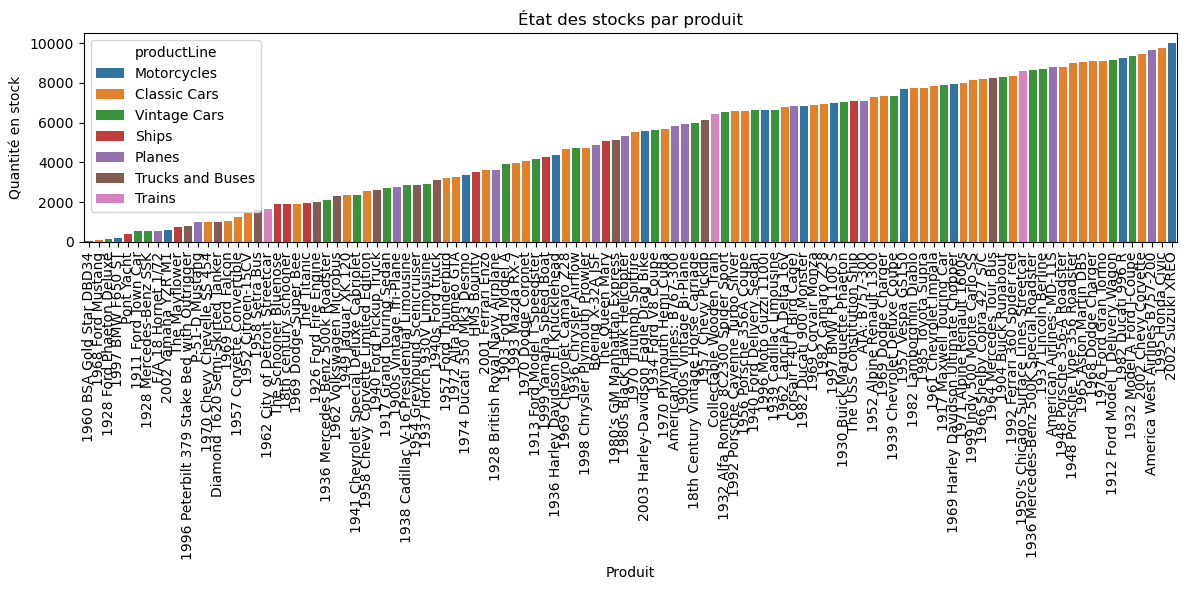

Produits en rupture de stock :
Empty DataFrame
Columns: [productCode, productName, quantityInStock]
Index: []

Produits à faible stock (<=50) :
  productCode               productName  quantityInStock
0    S24_2000  1960 BSA Gold Star DBD34               15


In [48]:
# -------------------------------
# PARTIE 5 : ANALYSE DES STOCKS
# -------------------------------

import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Dossier pour sauvegarder les plots
# -------------------------------
OUTPUT_DIR = os.path.join(os.path.expanduser("~"), "visualisations")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Plots seront sauvegardés ici :", OUTPUT_DIR)

# -------------------------------
# Connexion sécurisée MySQL
# -------------------------------
def get_connection():
    return mysql.connector.connect(
        host="localhost",
        user="root",
        password="visiteur",
        database="classicmodels"
    )

def fetch_data(query):
    conn = get_connection()
    df = pd.read_sql(query, conn)
    conn.close()
    return df

# -------------------------------
# Requête : état des stocks
# -------------------------------
query_stock = """
SELECT productCode, productName, productLine, quantityInStock
FROM products
ORDER BY quantityInStock ASC;
"""
df_stock = fetch_data(query_stock)

# -------------------------------
# Graphique des stocks par produit
# -------------------------------
plt.figure(figsize=(12,6))
sns.barplot(data=df_stock, x="productName", y="quantityInStock", hue="productLine", dodge=False)
plt.xticks(rotation=90)
plt.title("État des stocks par produit")
plt.xlabel("Produit")
plt.ylabel("Quantité en stock")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "stock_produits.png"))
plt.show()

# -------------------------------
# Identification des produits en rupture ou faible stock
# -------------------------------
rupture = df_stock[df_stock['quantityInStock'] == 0]
faible_stock = df_stock[df_stock['quantityInStock'] <= 50]

print("Produits en rupture de stock :")
print(rupture[['productCode','productName','quantityInStock']])
print("\nProduits à faible stock (<=50) :")
print(faible_stock[['productCode','productName','quantityInStock']])

In [54]:
# -------------------------------
# PARTIE 6 : RÉPARTITION DU CHIFFRE D'AFFAIRES PAR CLIENTS
# -------------------------------

import plotly.express as px
import pandas as pd
import os

# -------------------------------
# Requête : chiffre d'affaires par client
# -------------------------------
query_clients = """
SELECT 
    c.customerNumber,
    c.customerName,
    SUM(od.quantityOrdered * od.priceEach) AS chiffre_affaires
FROM customers c
JOIN orders o ON c.customerNumber = o.customerNumber
JOIN orderdetails od ON o.orderNumber = od.orderNumber
GROUP BY c.customerNumber, c.customerName
ORDER BY chiffre_affaires DESC;
"""
df_clients = fetch_data(query_clients)

# -------------------------------
# Catégorie : Top 10 clients vs autres
# -------------------------------
top_10 = df_clients.head(10)
autres = df_clients.iloc[10:].copy()

# Fusionner les autres en une seule ligne "Autres"
autres_sum = pd.DataFrame({
    'customerNumber': ['Autres'],
    'customerName': ['Autres'],
    'chiffre_affaires': [autres['chiffre_affaires'].sum()]
})

# Combiner Top 10 + Autres
df_plot = pd.concat([top_10, autres_sum], ignore_index=True)

# -------------------------------
# Graphique en camembert interactif
# -------------------------------
fig = px.pie(
    df_plot,
    names='customerName',
    values='chiffre_affaires',
    title="Répartition du chiffre d'affaires par clients (Top 10 vs Autres)",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_traces(textposition='inside', textinfo='percent+label')  # pour afficher % et nom
fig.write_html(os.path.join(OUTPUT_DIR, "ca_clients.html"))
fig.show()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_10960\466400808.py:31: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

